# Notebook 2 — FakeHealth · Baseline Classifier (full_data)
## Pipeline TF-IDF -> Classifieurs ML · Baseline 4 classes

**Projet :** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset :** full_data (claims.csv)  
**Objectif :** reproduire les mêmes baselines que NB2, en séparant 4 labels: `false`, `almost false`, `almost true`, `true`

---
### What does this notebook do?
1. Load `full_data/claims.csv`
2. Build a 4-class label from claim ratings
3. Prepare TF-IDF
4. Train baseline classifiers:
   - Logistic Regression
   - Naive Bayes
   - LinearSVC
5. Evaluate with 5-fold cross-validation
6. Evaluate on held-out test set (80/20)
7. Analyze errors and discriminant features
8. Produce a clean baseline table
9. Save trained models for later comparison with LLMs

---
## Section 1 — Installation & imports

In [56]:
# Décommentez si besoin :
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' Imports OK')

 Imports OK


---
## Section 2 — Data Loading (filtered thematic dataset)
Le notebook utilise le CSV filtré cardio + diabète généré depuis NB1 (`full_data/claims_cardio_diabete_filtered.csv`).

In [59]:
from pathlib import Path

CSV_PATH = Path('full_data/claims_cardio_diabete_filtered.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: full_data/claims_cardio_diabete_filtered.csv\n'
        'Run NB1 first to generate it.'
    )

raw_df = pd.read_csv(CSV_PATH, encoding='utf-8', low_memory=False)
print(f'All data loaded: {len(raw_df)} thematic claims')
print(f'CSV used: {CSV_PATH}')

All data loaded: 1075 thematic claims
CSV used: full_data/claims_cardio_diabete_filtered.csv


In [60]:
print('── Missing values (raw claims) ──')
print(raw_df.isnull().sum().to_string())
print()

# Mapping 4 classes des ratings
# accepte aussi les variantes 'mostly-*' et 'almost *'
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}

class_order = ['false', 'almost false', 'almost true', 'true']

df = raw_df.copy()
df['rating_norm'] = (
    df['rating']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['label_name'] = df['rating_norm'].map(rating_aliases)
df = df[df['label_name'].isin(class_order)].copy()

# id numérique (utile pour exports/compatibilité)
label_to_id = {c: i for i, c in enumerate(class_order)}
df['label'] = df['label_name'].map(label_to_id).astype(int)

# Colonne texte: combine name + statement + description
text_parts = []
for col in ['name', 'statement', 'description']:
    if col in df.columns:
        text_parts.append(df[col].fillna('').astype(str))

if not text_parts:
    raise ValueError('Aucune colonne texte exploitable parmi name/statement/description.')

df['text'] = text_parts[0]
for part in text_parts[1:]:
    df['text'] = df['text'] + ' ' + part

df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['text'].astype(bool)].copy()

# On conserve le rating brut pour l'analyse d'erreurs
if 'rating' in df.columns:
    df['rating_raw'] = df['rating']

print('── Dataset 4 classes construit depuis claims.csv ──')
print(f'Claims conservés : {len(df)}')
print('Répartition des classes:')
print(df['label_name'].value_counts().reindex(class_order, fill_value=0).to_string())
print('')
print('Répartition rating_norm (brut):')
print(df['rating_norm'].value_counts().to_string())

X = df['text'].values
y = df['label_name'].values

── Missing values (raw claims) ──
id                0
name           1027
statement         0
description     129
category          0
rating          122
queries        1027
created_at        0
updated_at        0

── Dataset 4 classes construit depuis claims.csv ──
Claims conservés : 645
Répartition des classes:
label_name
false           467
almost false     48
almost true      26
true            104

Répartition rating_norm (brut):
rating_norm
false           467
true            104
mostly-false     48
mostly-true      26


---
## Section 3 —  Train / Test
Use stratified split 80/20

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

train_counts = pd.Series(y_train).value_counts().reindex(class_order, fill_value=0)
test_counts = pd.Series(y_test).value_counts().reindex(class_order, fill_value=0)

print('── Split Train / Test ──')
print(f'  Train : {len(X_train)} claims')
print(train_counts.to_string())
print(f'  Test  : {len(X_test)} claims')
print(test_counts.to_string())

── Split Train / Test ──
  Train : 516 claims
false           374
almost false     38
almost true      21
true             83
  Test  : 129 claims
false           93
almost false    10
almost true      5
true            21


---
## Section 4 — Construction des pipelines TF-IDF

### Paramètres TF-IDF retenus
| Paramètre | Valeur | Justification |
|---|---|---|
| `ngram_range` | (1, 2) | Capture les expressions bi-mot ('heart disease', 'clinical trial') |
| `max_features` | 10 000 | Limite le bruit tout en couvrant le vocabulaire médical |
| `sublinear_tf` | True | Compresse les fréquences élevées (log(1+tf)) — standard NLP |
| `stop_words` | english | Retire les mots vides non informatifs |
| `min_df` | 2 | Ignore les termes n'apparaissant qu'une seule fois |
| `max_df` | 0.95 | Ignore les termes présents dans >95% des docs |


In [62]:
# Vectorizer common to both models
TFIDF_PARAMS = dict(
    ngram_range  = (1, 2),
    max_features = 10_000,
    sublinear_tf = True,
    stop_words   = 'english',
    min_df       = 2,
    max_df       = 0.95
)

# ── Pipeline 1 :  Logistic Regression ───────────────────────────────────
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LogisticRegression(
        C           = 1.0,       # regularization L2 standard
        max_iter    = 1000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced' 
    ))
])

# ── Pipeline 2 : Naive Bayes Multinomial ─────────────────────────────────
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  MultinomialNB(alpha=0.5))  # α=0.5 : lissage de Lidstone
])

# ── Pipeline 3 : LinearSVC
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LinearSVC(
        C           = 1.0,
        max_iter    = 2000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced'
    ))
])

models = {
    'Logistic Regression': pipe_lr,
    'Naive Bayes':         pipe_nb,
    'LinearSVC':           pipe_svm,
}


for name, pipe in models.items():
    print(f'   • {name}')

   • Logistic Regression
   • Naive Bayes
   • LinearSVC


---
## Section 5 — crossed validation


In [63]:
from sklearn.model_selection import cross_validate

# n_splits dynamique pour gérer les classes rares sur dataset filtré
min_class_count = pd.Series(y).value_counts().min()
n_splits = max(2, min(5, int(min_class_count)))
SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

print(f'Using StratifiedKFold with n_splits={n_splits} (min class count={min_class_count})')

cv_results = {}

for name, pipe in models.items():
    cv = cross_validate(
        pipe, X, y,
        cv      = SKF,
        scoring = {
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score = False,
        n_jobs = -1
    )
    cv_results[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()

Using StratifiedKFold with n_splits=5 (min class count=26)
── Logistic Regression ──
  Accuracy  : 0.6837 ± 0.0173
  F1 macro  : 0.3418 ± 0.0409
  Precision : 0.3731 ± 0.1086
  Recall    : 0.3424 ± 0.0278

── Naive Bayes ──
  Accuracy  : 0.7240 ± 0.0038
  F1 macro  : 0.2100 ± 0.0006
  Precision : 0.1810 ± 0.0009
  Recall    : 0.2500 ± 0.0000

── LinearSVC ──
  Accuracy  : 0.7302 ± 0.0216
  F1 macro  : 0.2843 ± 0.0242
  Precision : 0.3689 ± 0.1164
  Recall    : 0.2907 ± 0.0156



---
## Section 6 — Entraînement final et évaluation sur le test set
On entraîne sur le train set complet et on évalue sur le test set réservé.

In [64]:
test_results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    report_dict = classification_report(
        y_test, y_pred,
        labels=class_order,
        target_names=class_order,
        output_dict=True,
        zero_division=0
    )

    per_class_f1 = {
        c: float(report_dict.get(c, {}).get('f1-score', 0.0))
        for c in class_order
    }

    test_results[name] = {
        'y_pred'         : y_pred,
        'accuracy'       : accuracy_score(y_test, y_pred),
        'prec_macro'     : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'rec_macro'      : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro'       : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_weighted'    : f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'per_class_f1'   : per_class_f1,
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(
        y_test, y_pred,
        labels=class_order,
        target_names=class_order,
        zero_division=0
    ))

── Logistic Regression — Test Set ──
              precision    recall  f1-score   support

       false       0.75      0.83      0.79        93
almost false       0.33      0.20      0.25        10
 almost true       0.00      0.00      0.00         5
        true       0.29      0.29      0.29        21

    accuracy                           0.66       129
   macro avg       0.34      0.33      0.33       129
weighted avg       0.62      0.66      0.64       129

── Naive Bayes — Test Set ──
              precision    recall  f1-score   support

       false       0.72      1.00      0.84        93
almost false       0.00      0.00      0.00        10
 almost true       0.00      0.00      0.00         5
        true       0.00      0.00      0.00        21

    accuracy                           0.72       129
   macro avg       0.18      0.25      0.21       129
weighted avg       0.52      0.72      0.60       129

── LinearSVC — Test Set ──
              precision    recall  f1

---
## Section 7 — confused matrix

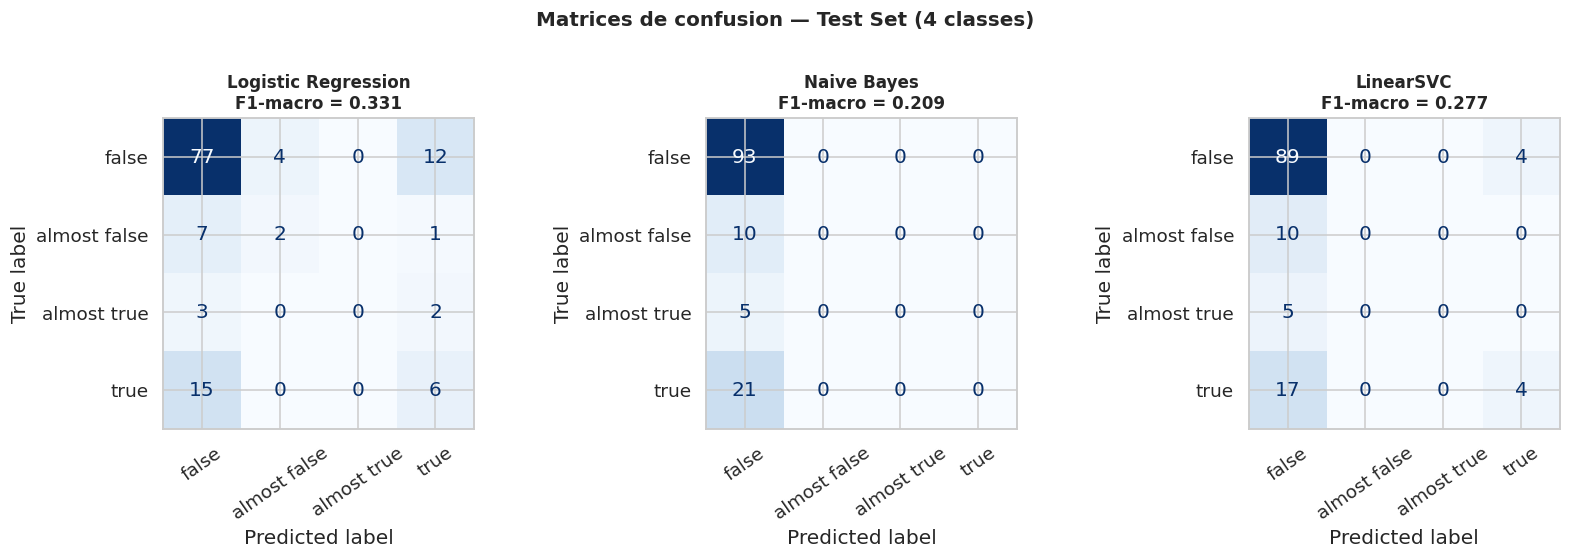

 Sauvegardé : fig6_confusion_matrices_4classes.png


In [65]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.8))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=35)
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}', fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — Test Set (4 classes)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices_4classes.png', bbox_inches='tight', dpi=130)
plt.show()
print(' Sauvegardé : fig6_confusion_matrices_4classes.png')

---
## Section 8 — Features most discriminants
Pour la Régression Logistique,  coefficients indicates wchich word move on Fake ou Real.

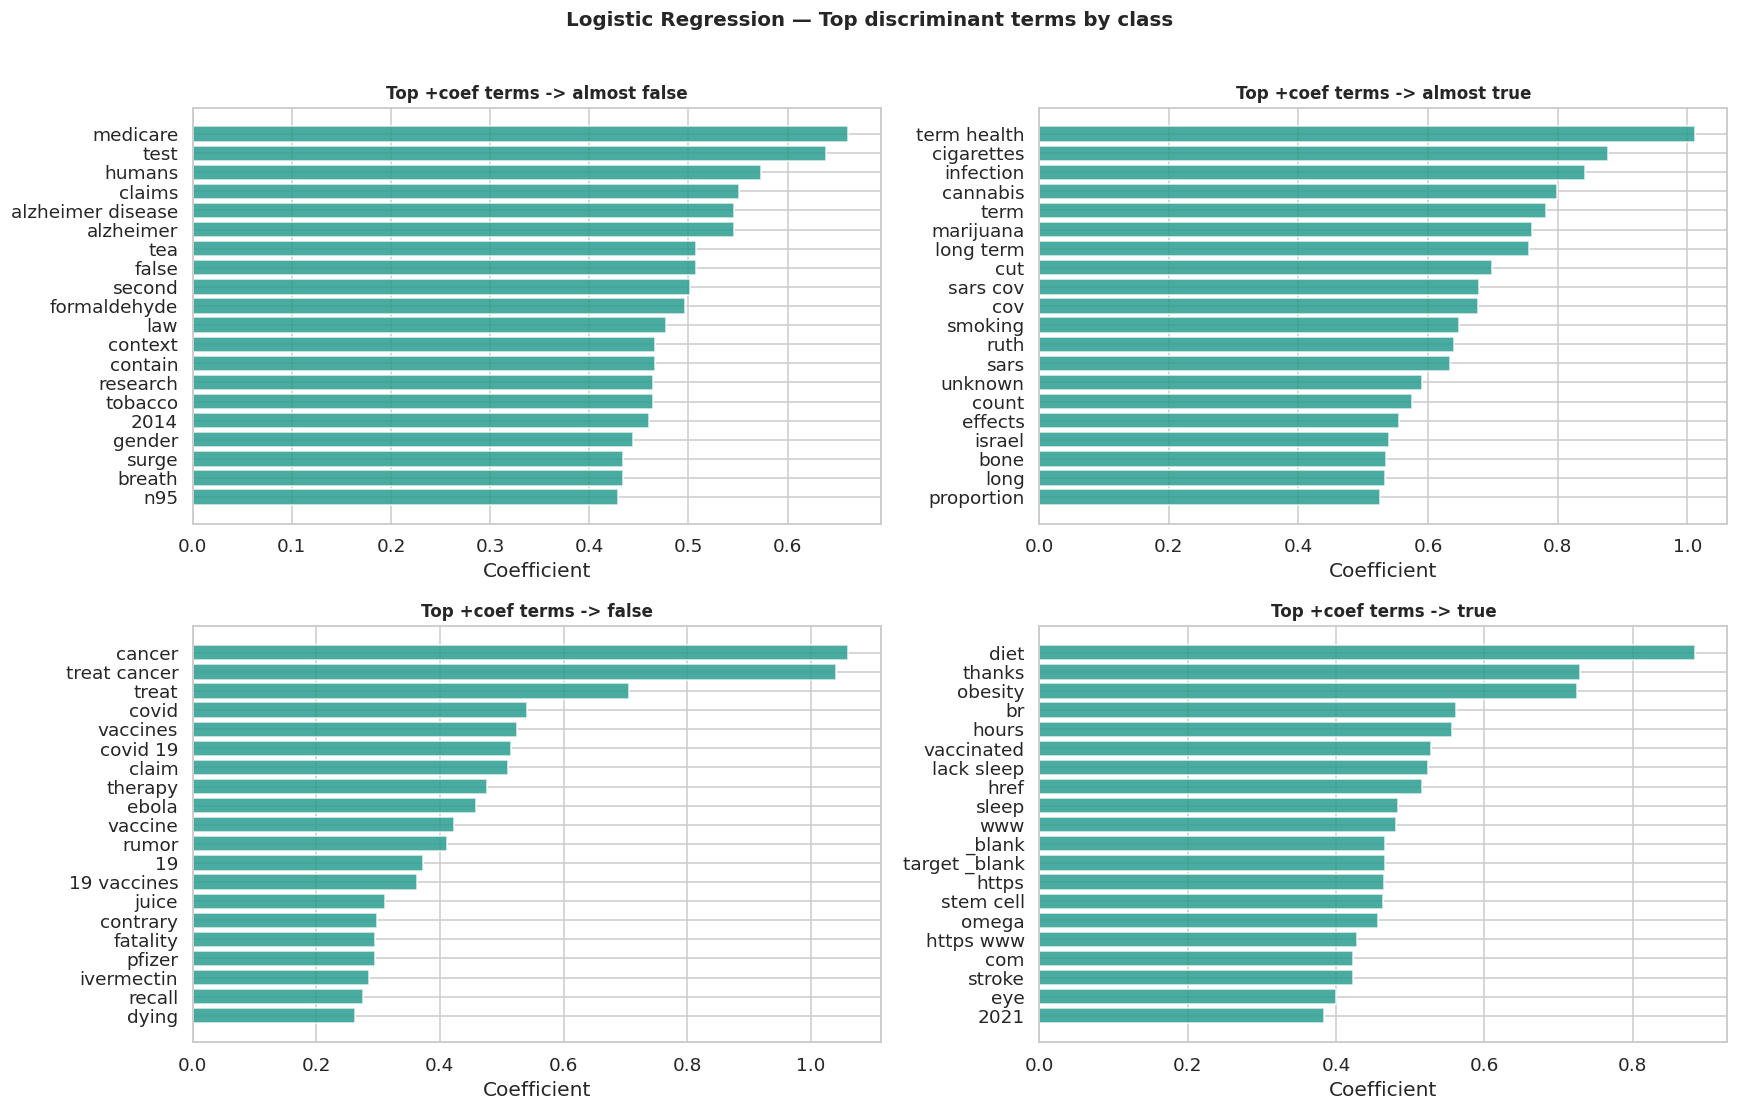

Sauvegarde: fig7_feature_importance_4classes.png
Target terms matched in TF-IDF vocabulary:
  Found: 38 / 88


,group,term,matched_features,n_matched_features,best_class,best_coef
23,cardiovascular_risk_factors,obesity,obesity,1,true,0.724994
21,cardiovascular_risk_factors,smoking,smoking,1,almost true,0.647760
67,diabetes_biomarkers,glucose tolerance test,"glucose, test",2,almost false,0.462702
6,cardiovascular_diseases,stroke,stroke,1,true,0.422317
45,diabetes_types,type 1 diabetes,"type, diabetes",2,almost false,0.319229
46,diabetes_types,type 2 diabetes,"type, diabetes",2,almost false,0.319229
81,medical_general_terms,hospital,hospital,1,true,0.267629
28,cardiovascular_risk_factors,diabetes,diabetes,1,almost false,0.254509
80,medical_general_terms,patient,patient,1,true,0.225427
14,cardiovascular_symptoms,shortness of breath,"shortness, breath",2,almost false,0.224588


In [66]:
import re

# Extraction des features importantes (Logistic Regression multiclasse)
lr_pipe = models['Logistic Regression']
vectorizer = lr_pipe.named_steps['tfidf']
classifier = lr_pipe.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
classes = list(classifier.classes_)

# Top features par classe (one-vs-rest)
TOP_N = 20
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, cls_name in zip(axes, classes):
    cls_idx = classes.index(cls_name)
    coefs = classifier.coef_[cls_idx]
    top_idx = np.argsort(coefs)[-TOP_N:]

    terms = feature_names[top_idx]
    vals = coefs[top_idx]
    order = np.argsort(vals)

    ax.barh(np.array(terms)[order], np.array(vals)[order], color='#2a9d8f', alpha=0.85)
    ax.set_title(f'Top +coef terms -> {cls_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Logistic Regression — Top discriminant terms by class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_feature_importance_4classes.png', bbox_inches='tight', dpi=130)
plt.show()
print('Sauvegarde: fig7_feature_importance_4classes.png')

# Analyse ciblée sur les termes médicaux hérités de NB1
cardiovascular_diseases = [
    'cardiovascular disease', 'heart disease', 'coronary artery disease',
    'ischemic heart disease', 'myocardial infarction', 'heart attack',
    'stroke', 'ischemic stroke', 'hypertension', 'high blood pressure',
    'heart failure', 'arrhythmia'
]

cardiovascular_symptoms = [
    'chest pain', 'angina', 'shortness of breath', 'dyspnea', 'palpitations',
    'fatigue', 'dizziness', 'syncope', 'edema'
]

cardiovascular_risk_factors = [
    'smoking', 'tobacco use', 'obesity', 'bmi', 'high cholesterol', 'ldl', 'hdl',
    'diabetes', 'sedentary lifestyle', 'family history', 'age'
]

cardiovascular_treatments = [
    'statins', 'beta-blockers', 'antihypertensive drugs', 'aspirin therapy',
    'angioplasty', 'stent', 'bypass surgery'
]

cardiovascular_tests = [
    'ecg', 'electrocardiogram', 'blood pressure', 'cholesterol levels',
    'troponin', 'echocardiogram'
]

diabetes_types = [
    'type 1 diabetes', 'type 2 diabetes', 'gestational diabetes', 'prediabetes'
]

diabetes_symptoms = [
    'frequent urination', 'polyuria', 'excessive thirst', 'polydipsia',
    'fatigue', 'weight loss', 'blurred vision', 'slow wound healing'
]

diabetes_treatments = [
    'insulin', 'metformin', 'glucose-lowering drugs', 'glp-1 agonists',
    'lifestyle intervention', 'diet control'
]

diabetes_biomarkers = [
    'blood glucose', 'fasting glucose', 'hba1c', 'insulin level', 'glucose tolerance test'
]

diabetes_complications = [
    'neuropathy', 'nephropathy', 'retinopathy', 'cardiovascular disease', 'diabetic foot ulcer'
]

medical_general_terms = [
    'risk factor', 'prevalence', 'incidence', 'mortality', 'clinical trial',
    'diagnosis', 'treatment outcome', 'patient', 'hospital', 'clinical study',
    'randomized controlled trial', 'medical record', 'electronic health records',
    'clinical notes', 'medical report'
]

term_groups = {
    'cardiovascular_diseases': cardiovascular_diseases,
    'cardiovascular_symptoms': cardiovascular_symptoms,
    'cardiovascular_risk_factors': cardiovascular_risk_factors,
    'cardiovascular_treatments': cardiovascular_treatments,
    'cardiovascular_tests': cardiovascular_tests,
    'diabetes_types': diabetes_types,
    'diabetes_symptoms': diabetes_symptoms,
    'diabetes_treatments': diabetes_treatments,
    'diabetes_biomarkers': diabetes_biomarkers,
    'diabetes_complications': diabetes_complications,
    'medical_general_terms': medical_general_terms,
}

def _normalize_term(term):
    return re.sub(r'\s+', ' ', str(term).strip().lower())

def _extract_matching_ngrams(term):
    t = _normalize_term(term)
    tokens = re.findall(r'[a-z0-9]+', t)
    if not tokens:
        return []
    if len(tokens) <= 2:
        return [' '.join(tokens)]
    cands = [' '.join(tokens[i:i+2]) for i in range(len(tokens) - 1)]
    cands.extend(tokens)
    seen = set()
    out = []
    for c in cands:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out

rows = []
for group_name, terms in term_groups.items():
    for term in terms:
        candidates = _extract_matching_ngrams(term)
        matched = [c for c in candidates if c in feature_names]

        if not matched:
            rows.append({
                'group': group_name,
                'term': term,
                'matched_features': '',
                'n_matched_features': 0,
                'best_class': 'not_found',
                'best_coef': np.nan,
            })
            continue

        idx = [np.where(feature_names == m)[0][0] for m in matched]
        mean_by_class = classifier.coef_[:, idx].mean(axis=1)
        best_i = int(np.argmax(mean_by_class))

        rows.append({
            'group': group_name,
            'term': term,
            'matched_features': ', '.join(matched),
            'n_matched_features': len(matched),
            'best_class': classes[best_i],
            'best_coef': float(mean_by_class[best_i]),
        })

target_df = pd.DataFrame(rows)
target_found = target_df[target_df['n_matched_features'] > 0].copy()

print('Target terms matched in TF-IDF vocabulary:')
print(f'  Found: {len(target_found)} / {len(target_df)}')
if not target_found.empty:
    display(target_found.sort_values('best_coef', ascending=False).head(30))

---
## Section 9 — Analyse des erreurs
Quels articles sont mal classifiés ? Y a-t-il des patterns dans les erreurs ?

In [67]:
# Analyse d'erreurs (multiclasse) avec LR comme modèle principal
y_pred_lr = test_results['Logistic Regression']['y_pred']

all_indices = np.arange(len(df))
_, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['label_name']
)

test_df = df.iloc[test_indices].copy().reset_index(drop=True)
test_df['y_true'] = np.asarray(y_test)
test_df['y_pred'] = np.asarray(y_pred_lr)
test_df['correct'] = (test_df['y_true'] == test_df['y_pred'])

errors = test_df[~test_df['correct']].copy()

print(f'Erreurs totales : {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)')
print()

conf_pairs = (
    errors.groupby(['y_true', 'y_pred'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print('Top confusions (true -> predicted):')
if conf_pairs.empty:
    print('  Aucune erreur.')
else:
    print(conf_pairs.head(10).to_string(index=False))

Erreurs totales : 44 / 129 (34.1%)

Top confusions (true -> predicted):
      y_true       y_pred  count
        true        false     15
       false         true     12
almost false        false      7
       false almost false      4
 almost true        false      3
 almost true         true      2
almost false         true      1


In [68]:
print('── Exemples d’erreurs par paire de confusion (LR) ──')

if errors.empty:
    print('Aucune erreur sur le test set.')
else:
    shown = 0
    for _, pair in conf_pairs.head(4).iterrows():
        true_c = pair['y_true']
        pred_c = pair['y_pred']
        subset = errors[(errors['y_true'] == true_c) & (errors['y_pred'] == pred_c)]
        if subset.empty:
            continue

        row = subset.iloc[0]
        txt = str(row.get('text', row.get('statement', 'N/A')))[:300]
        rating = row.get('rating_raw', row.get('rating_norm', 'N/A'))

        print(f'\nTrue={true_c} -> Pred={pred_c} | example rating={rating}')
        print(f'  {txt}...')
        shown += 1

    if shown == 0:
        print('Pas d’exemple disponible.')

── Exemples d’erreurs par paire de confusion (LR) ──

True=true -> Pred=false | example rating=true
  The FDA has updated its warnings for — and recommended limitations on — prescribing a class of antibiotics called fluoroquinolones, citing potentially irreversible side-effects including tendon damage and rupture. Could Cipro and Other Fluoroquinolone Antibiotics Cause Irreversible Tendon Damage? Th...

True=false -> Pred=true | example rating=false
  Photograph shows a patient who received a severe penile burn from urinating on an electric fence. Does a Photograph Show a Penile Burn from an Electric Fence? Photograph purportedly shows a medical patient who received a severe penile burn from urinating on an electric fence. Although tales about me...

True=almost false -> Pred=false | example rating=mostly-false
  There is a proven natural cure for cancer called sour honey, but pharmaceutical companies and politicians are trying to keep it under wraps for financial gain. “Sour Honey’ is

---
## Section 10 — Comparaison des modèles (visualisation)
Graphique comparatif des métriques pour les 3 modèles.

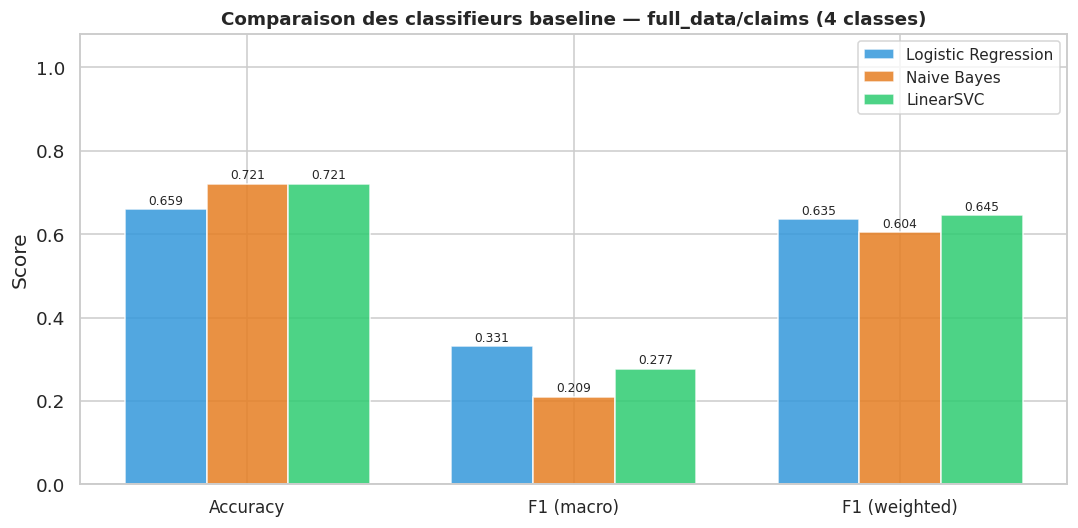

 Sauvegardé : fig9_model_comparison_claims_4classes.png


In [69]:
# Données de comparaison (multiclasse)
metrics = ['accuracy', 'f1_macro', 'f1_weighted']
metric_labels = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']

x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, res) in enumerate(test_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparaison des classifieurs baseline — full_data/claims (4 classes)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig9_model_comparison_claims_4classes.png', bbox_inches='tight', dpi=130)
plt.show()
print(' Sauvegardé : fig9_model_comparison_claims_4classes.png')

---
## Section 11 — TABLE 1 (rapport final)
Ce tableau constitue la **Table 1** du rapport, qui servira de référence pour comparer les LLMs.

In [71]:
print('=' * 92)
print('TABLE 1 — Baseline Classifier Performance — cardio+diabete filtered claims (4 classes)')
print('Classes  : false | almost false | almost true | true')
print('Features : TF-IDF unigrammes + bigrammes (max 10 000 features)')
print('Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV')
print('=' * 92)

header = f'{"Modèle":<24} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-w":>7} {"CV F1±σ":>13}'
print(header)
print('-' * 92)

for name, res in test_results.items():
    cv = cv_results[name]
    cv_f1_mean = cv['test_f1_macro'].mean()
    cv_f1_std = cv['test_f1_macro'].std()
    row = (
        f'{name:<24} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_weighted"]:>7.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('-' * 92)
print('\nF1 par classe (test set):')
for name, res in test_results.items():
    f1c = res['per_class_f1']
    print(
        f'  {name:<24} '
        f'false={f1c["false"]:.3f} | '
        f'almost false={f1c["almost false"]:.3f} | '
        f'almost true={f1c["almost true"]:.3f} | '
        f'true={f1c["true"]:.3f}'
    )

print('\nNotes :')
print('  • Sous-dataset filtré sur mots-clés cardio + diabète')
print('  • F1-macro = métrique principale pour équilibrer les classes')
print('  • F1-weighted reflète la performance globale')

TABLE 1 — Baseline Classifier Performance — cardio+diabete filtered claims (4 classes)
Classes  : false | almost false | almost true | true
Features : TF-IDF unigrammes + bigrammes (max 10 000 features)
Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV
Modèle                       Acc    Prec  Recall  F1-mac    F1-w       CV F1±σ
--------------------------------------------------------------------------------------------
Logistic Regression        0.659   0.343   0.328   0.331   0.635  0.342±0.041
Naive Bayes                0.721   0.180   0.250   0.209   0.604  0.210±0.001
LinearSVC                  0.721   0.309   0.287   0.277   0.645  0.284±0.024
--------------------------------------------------------------------------------------------

F1 par classe (test set):
  Logistic Regression      false=0.790 | almost false=0.250 | almost true=0.000 | true=0.286
  Naive Bayes              false=0.838 | almost false=0.000 | almost true=0.000 | true=0.000
  LinearSVC     

In [72]:
# Export de la table en CSV pour le rapport
rows = []
for name, res in test_results.items():
    cv = cv_results[name]
    row = {
        'Model': name,
        'Accuracy': round(res['accuracy'], 3),
        'Precision': round(res['prec_macro'], 3),
        'Recall': round(res['rec_macro'], 3),
        'F1_macro': round(res['f1_macro'], 3),
        'F1_weighted': round(res['f1_weighted'], 3),
        'CV_F1_mean': round(cv['test_f1_macro'].mean(), 3),
        'CV_F1_std': round(cv['test_f1_macro'].std(), 3),
        'F1_false': round(res['per_class_f1']['false'], 3),
        'F1_almost_false': round(res['per_class_f1']['almost false'], 3),
        'F1_almost_true': round(res['per_class_f1']['almost true'], 3),
        'F1_true': round(res['per_class_f1']['true'], 3),
        'Features': 'TF-IDF (1-2gram, max=10k)',
        'Dataset': 'claims_cardio_diabete_filtered',
    }
    rows.append(row)

table1 = pd.DataFrame(rows)
table1.to_csv('Table1_baseline_results_claims_cardio_diabete_4classes.csv', index=False)
print('Sauvegardé : Table1_baseline_results_claims_cardio_diabete_4classes.csv')
print()
print(table1.to_string(index=False))

Sauvegardé : Table1_baseline_results_claims_cardio_diabete_4classes.csv

              Model  Accuracy  Precision  Recall  F1_macro  F1_weighted  CV_F1_mean  CV_F1_std  F1_false  F1_almost_false  F1_almost_true  F1_true                  Features                        Dataset
Logistic Regression     0.659      0.343   0.328     0.331        0.635       0.342      0.041     0.790             0.25             0.0    0.286 TF-IDF (1-2gram, max=10k) claims_cardio_diabete_filtered
        Naive Bayes     0.721      0.180   0.250     0.209        0.604       0.210      0.001     0.838             0.00             0.0    0.000 TF-IDF (1-2gram, max=10k) claims_cardio_diabete_filtered
          LinearSVC     0.721      0.309   0.287     0.277        0.645       0.284      0.024     0.832             0.00             0.0    0.276 TF-IDF (1-2gram, max=10k) claims_cardio_diabete_filtered


---
## Section 12 — Sauvegarde des modèles
On sauvegarde les pipelines entraînés pour les comparer avec les LLMs en Phase 2.

In [ ]:
os.makedirs('models', exist_ok=True)

for name, pipe in models.items():
    safe_name = name.lower().replace(' ', '_')
    path = f'models/{safe_name}_claims_cardio_diabete_4classes.pkl'
    joblib.dump(pipe, path)
    print(f' {name} -> {path}')

# Sauvegarde du test set pour évaluation comparative LLM
label_to_id = {c: i for i, c in enumerate(class_order)}
test_export = pd.DataFrame({
    'text': X_test,
    'label_name': y_test,
})
test_export['label'] = test_export['label_name'].map(label_to_id).astype(int)
test_export.to_csv('claims_cardio_diabete_test_set_4classes.csv', index=False)
print(f' Test set -> claims_cardio_diabete_test_set_4classes.csv ({len(test_export)} claims)')
print()

 Logistic Regression -> models/logistic_regression_claims_cardio_diabete_4classes.pkl
 Naive Bayes -> models/naive_bayes_claims_cardio_diabete_4classes.pkl
 LinearSVC -> models/linearsvc_claims_cardio_diabete_4classes.pkl
 Test set -> claims_cardio_diabete_test_set_4classes.csv (129 claims)

 Prêt pour la Phase 2 : évaluation des LLMs sur le même test set (4 classes)
